# Tension Statistics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/dev/examples/04-inference/tension_statistics.ipynb)

"These two measurements disagree at 4σ" is a claim that needs a
definition, and there is more than one. `CosmoFit.stats.tension`
carries four, each appropriate to a different situation:

| function | needs | handles |
|---|---|---|
| `gaussian_tension` | two numbers ± errors | one parameter, Gaussian |
| `sample_tension` | two sets of samples | one parameter, any shape |
| `gaussian_tension_nd` | two means + covariances | several parameters at once |
| `suspiciousness` | three nested-sampling runs | prior dependence removed |

The differences between them are not cosmetic. This notebook works
through the H₀ tension with each.

## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e ".[evidence]"

    # The editable install runs in a subprocess, so this already-running
    # kernel does not see the .pth it writes -- and `import CosmoFit`
    # would resolve to the bare checkout directory instead (same name,
    # and /content is on sys.path). Point sys.path at src/ directly.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e \".[evidence]\" from the repository root).")

Not running in Colab -- assuming CosmoFit is already installed (pip install -e ".[evidence]" from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Fitter
from CosmoFit.cosmology.models import LCDM
from CosmoFit.stats.tension import (
    gaussian_tension, gaussian_tension_nd, sample_tension, suspiciousness,
)

plt.rcParams["figure.dpi"] = 110

## 1. The textbook case: two numbers

The H₀ tension as it is usually quoted — Planck 2018's CMB-inferred
value against SH0ES' Cepheid-calibrated distance ladder.

In [3]:
planck = (67.36, 0.54)      # Planck 2018 TT,TE,EE+lowE+lensing
shoes = (73.04, 1.04)       # Riess et al. 2022

result = gaussian_tension(planck[0], planck[1], shoes[0], shoes[1])
for key, value in result.items():
    print(f"  {key:16s} = {value:.6g}")

  difference       = -5.68
  combined_sigma   = 1.17184
  n_sigma          = 4.84709
  p_value          = 1.25283e-06


That assumes both posteriors are Gaussian, one-dimensional and
independent. The first of those is the one that usually fails.

## 2. From samples, with no Gaussian assumption

`sample_tension` builds the distribution of the *difference* by
pairing samples at random: if the two are independent, that is
exactly what `a - b` is distributed as. Perfect agreement puts its
peak at zero; a tension pushes zero into its tail.

The quoted probability is the fraction of the difference
distribution at **higher density** than zero — so a skewed or
double-peaked difference is handled correctly, where "how many
standard deviations from zero" would not be.

Two real posteriors to compare: `H0` from BAO+BBN-style data against
`H0` from supernovae plus chronometers.

In [4]:
COMMON = {"H0": 70.0, "Omega_m": 0.3, "rd": 147.0}

bao = Fitter(
    model=LCDM, datasets=["desi", "omega_b"],
    free_params=["H0", "Omega_m", "Omega_b"],
    initial=COMMON, compute_rd=True,
)
bao.run_mcmc(nwalkers=24, nsteps=3000, burnin=600, seed=0, progress=True)

late = Fitter(
    model=LCDM, datasets=["cc", "pantheon"],
    free_params=["H0", "Omega_m"],
    initial=COMMON,
)
late.run_mcmc(nwalkers=24, nsteps=3000, burnin=600, seed=0, progress=True)

for label, f in [("BAO + BBN", bao), ("CC + Pantheon+", late)]:
    s = f.summary()["H0"]
    print(f"  {label:16s} H0 = {s['median']:.2f} "
          f"-{s['minus']:.2f} +{s['plus']:.2f}")

  0%|          | 0/3000 [00:00<?, ?it/s]


  1%|          | 19/3000 [00:00<00:15, 189.97it/s]


  1%|▏         | 39/3000 [00:00<00:15, 192.54it/s]


  2%|▏         | 59/3000 [00:00<00:15, 195.17it/s]


  3%|▎         | 79/3000 [00:00<00:14, 197.01it/s]


...

 99%|█████████▉| 2981/3000 [00:37<00:00, 80.34it/s]


100%|█████████▉| 2990/3000 [00:38<00:00, 77.82it/s]


100%|█████████▉| 2998/3000 [00:38<00:00, 77.10it/s]


100%|██████████| 3000/3000 [00:38<00:00, 78.56it/s]


  BAO + BBN        H0 = 68.68 -0.78 +0.83
  CC + Pantheon+   H0 = 67.65 -3.14 +3.25


In [5]:
h0_bao = bao.samples_dict()["H0"]
h0_late = late.samples_dict()["H0"]

result = sample_tension(h0_bao, h0_late, seed=0)
for key, value in result.items():
    if np.ndim(value) == 0:                 # the difference samples
        print(f"  {key:18s} = {value:.6g}")  # come back too; skip them

  n_sigma            = 0.370802
  p_value            = 0.710785
  median_difference  = 1.04561


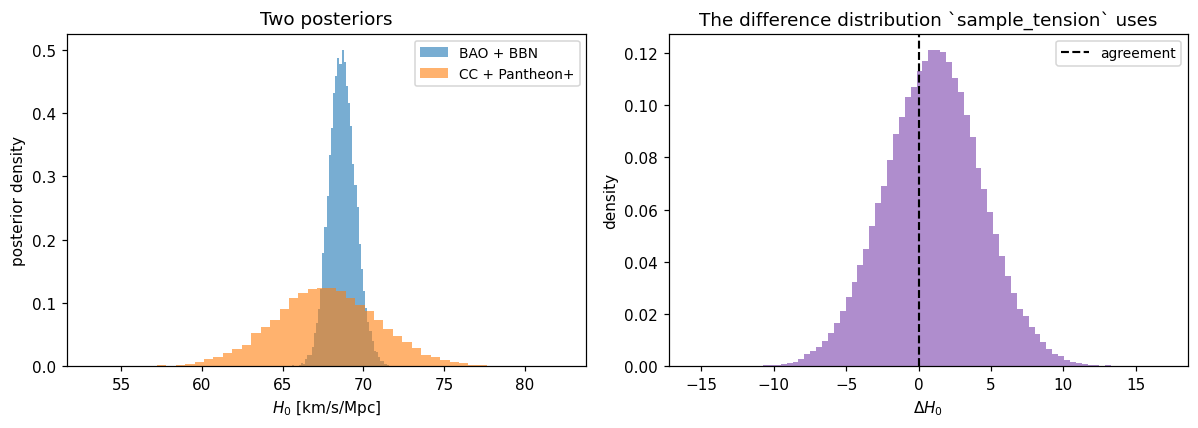

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(h0_bao, bins=50, density=True, alpha=0.6, label="BAO + BBN")
axes[0].hist(h0_late, bins=50, density=True, alpha=0.6, label="CC + Pantheon+")
axes[0].set_xlabel("$H_0$ [km/s/Mpc]")
axes[0].set_ylabel("posterior density")
axes[0].set_title("Two posteriors")
axes[0].legend(fontsize=9)

rng = np.random.default_rng(0)
difference = (rng.choice(h0_bao, 200_000) - rng.choice(h0_late, 200_000))
axes[1].hist(difference, bins=80, density=True, color="tab:purple", alpha=0.75)
axes[1].axvline(0.0, color="k", lw=1.4, ls="--", label="agreement")
axes[1].set_xlabel(r"$\Delta H_0$")
axes[1].set_ylabel("density")
axes[1].set_title("The difference distribution `sample_tension` uses")
axes[1].legend(fontsize=9)

fig.tight_layout()

## 3. Tension in a plane

A joint statistic is **not** the larger of its one-dimensional
projections, and it is not the smaller one either — it asks a
different question. `gaussian_tension_nd` tests whether the whole
difference *vector* is consistent with zero, over `n` degrees of
freedom, so it accounts both for a disagreement that lives in a
direction no single parameter shows, and for the extra freedom
that `n` dimensions bring.

Which way it comes out depends on the geometry. Two posteriors
can overlap in every parameter separately and still be far apart
jointly, if their degeneracy directions differ. They can equally
disagree in one projection and be comfortable jointly, if the
shift lies along a shared degeneracy — which is what happens
below.

In [7]:
def moments(fitter, names):
    samples = fitter.samples_dict()
    stack = np.column_stack([samples[n] for n in names])
    return stack.mean(axis=0), np.cov(stack, rowvar=False)


names = ["H0", "Omega_m"]
mean_a, cov_a = moments(bao, names)
mean_b, cov_b = moments(late, names)

nd = gaussian_tension_nd(mean_a, cov_a, mean_b, cov_b)
for key, value in nd.items():
    print(f"  {key:16s} = {value:.6g}")

print("\nOne parameter at a time, for comparison:")
print("(not the same question -- see above)")
for i, name in enumerate(names):
    one = gaussian_tension(mean_a[i], np.sqrt(cov_a[i, i]),
                           mean_b[i], np.sqrt(cov_b[i, i]))
    print(f"  {name:8s}: {one['n_sigma']:.2f} sigma")

  chi2             = 2.3967
  dof              = 2
  p_value          = 0.301692
  n_sigma          = 1.03281
One parameter at a time, for comparison:
(not the same question -- see above)
  H0      : 0.31 sigma
  Omega_m : 1.55 sigma


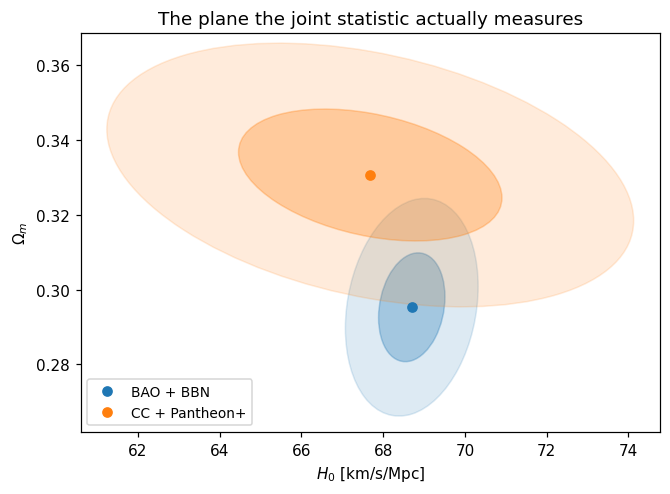

In [8]:
from matplotlib.patches import Ellipse


def ellipse(ax, mean, cov, n_sigma, **kwargs):
    values, vectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vectors[1, -1], vectors[0, -1]))
    width, height = 2 * n_sigma * np.sqrt(values[::-1])
    ax.add_patch(Ellipse(mean, width, height, angle=angle, **kwargs))


fig, ax = plt.subplots(figsize=(6.2, 4.6))
for mean, cov, colour, label in [
    (mean_a, cov_a, "tab:blue", "BAO + BBN"),
    (mean_b, cov_b, "tab:orange", "CC + Pantheon+"),
]:
    for n in (1, 2):
        ellipse(ax, mean, cov, n, facecolor=colour,
                alpha=0.30 if n == 1 else 0.15, edgecolor=colour)
    ax.plot(*mean, "o", color=colour, label=label)

ax.set_xlabel("$H_0$ [km/s/Mpc]")
ax.set_ylabel(r"$\Omega_m$")
ax.set_title("The plane the joint statistic actually measures")
ax.legend(fontsize=9)
fig.tight_layout()

## 4. Suspiciousness: tension without the prior

The evidence ratio

$$\ln R = \ln Z_{{AB}} - \ln Z_A - \ln Z_B$$

measures whether two datasets prefer to be described together. But
it moves with the prior volume — widen a prior and `R` rises, with
nothing about the data changed.

Handley & Lemos' **suspiciousness** subtracts the information the
data gained,

$$\ln S = \ln R - \ln I, \qquad \ln I = D_A + D_B - D_{{AB}},$$

where `D` is each run's Kullback–Leibler divergence from prior to
posterior. That carries the same prior dependence and cancels it.
What is left is a statement about the data.

It needs three nested-sampling runs over the **same** parameters and
priors: each dataset alone, and both together.

In [9]:
PARAMS = ["H0", "Omega_m", "rd"]
BOUNDS = {"H0": (55.0, 85.0), "Omega_m": (0.1, 0.6),
          "rd": (120.0, 175.0)}


def nested_for(datasets):
    f = Fitter(model=LCDM, datasets=datasets, free_params=PARAMS,
               initial=COMMON, bounds=BOUNDS)
    return f.run_nested(n_live=350, dlogz=0.15, seed=0, progress=False)


run_bao = nested_for(["desi"])
run_sn = nested_for(["pantheon"])
run_joint = nested_for(["desi", "pantheon"])

for label, run in [("DESI", run_bao), ("Pantheon+", run_sn),
                   ("both", run_joint)]:
    print(f"  {label:10s} ln Z = {run.log_evidence:9.3f} "
          f"+/- {run.log_evidence_error:.3f}")

  DESI       ln Z =   -12.574 +/- 0.163
  Pantheon+  ln Z =  -730.503 +/- 0.098
  both       ln Z =  -742.497 +/- 0.167


In [10]:
result = suspiciousness(joint=run_joint, first=run_bao, second=run_sn)
for key, value in result.items():
    print(f"  {key:10s} = {value:.6g}")

print("\nln R alone would move if these priors were widened;")
print("ln S is what survives that.")

  ln_S       = -0.974954
  ln_R       = 0.579364
  ln_I       = 1.55432
  d          = 3
  chi2       = 4.94991
  p_value    = 0.175502
  n_sigma    = 1.35473
ln R alone would move if these priors were widened;
ln S is what survives that.


## 5. Which one to reach for

- **`gaussian_tension`** when both numbers really are Gaussian and
  independent — quoting two published values against each other.
- **`sample_tension`** when you have chains. It costs nothing extra
  and makes no shape assumption, so there is rarely a reason not to
  use it instead.
- **`gaussian_tension_nd`** whenever the disagreement might live in
  a *direction* rather than in a single parameter.
- **`suspiciousness`** when the comparison will be quoted and the
  priors are wide or arbitrary, so that a bare evidence ratio would
  be reporting the prior as much as the data.

The S₈ tension gets the same treatment from the CMB side in
[`../05-case-studies/s8_tension_cmb.ipynb`](../05-case-studies/s8_tension_cmb.ipynb),
and the H₀ tension is the whole subject of
[`../05-case-studies/lscdm_mcmc.ipynb`](../05-case-studies/lscdm_mcmc.ipynb).